# Notebook Objective


# 07 Fleet-Level Maintenance Cost Simulation

This notebook translates RUL predictions into fleet-level maintenance decisions and simulated costs.

The main objectives are:

- recreate the RUL prediction pipeline and train the selected XGBoost model
- build rolling predictions for run-to-failure validation engines
- split validation engines into conformal calibration engines and simulation fleet engines
- construct uncertainty-aware RUL intervals using conformal prediction
- define transparent point-estimate and uncertainty-aware maintenance policies
- simulate maintenance scheduling chronologically for each engine in the fleet
- compare fleet-level cost, failures, planned maintenance and unused useful life
- analyze how maintenance thresholds change the cost trade-off

The simulation is still simplified, but it is fleet-level and rolling: each engine is evaluated over consecutive windows until maintenance is triggered or the engine reaches failure.


# Imports and Project Setup


In [52]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [53]:
from src.data_loading import DATASET_IDS
from src.config import load_config, flatten_config
from src.pipeline import recreate_prediction_pipeline
from src.models import build_xgboost_model


# Recreate Prediction Pipeline

The preprocessing, feature engineering and XGBoost training workflow is recreated from the project configuration.

The default project validation split remains unchanged for the model-comparison and explainability notebooks. For this fleet-level simulation only, the notebook applies the simulation-specific `fleet_validation_size` from `src/config.py`. For FD001, this uses a `fleet_validation_size` of `0.3`, creating approximately 70 training engines and 30 held-out validation engines inside this notebook. The model is trained only on the training engines.

The fleet simulation deliberately uses validation run-to-failure engines instead of the official C-MAPSS test engines. The official test set provides the true RUL only for the final observed cycle of each engine. A rolling maintenance simulation, however, needs the true RUL at many decision points along an engine trajectory. The validation engines come from the run-to-failure training data, so their true RUL is known for every generated sliding window.

The resulting data split is therefore interpreted as:

- training engines: used to fit the XGBoost RUL model
- validation engines: held out from model training and used for simulation-related evaluation
- calibration engines: subset of validation engines used only to calibrate conformal interval width
- simulation fleet engines: separate subset of validation engines used for rolling fleet-level cost simulation

This keeps model fitting, uncertainty calibration and fleet-cost evaluation separated by engine unit without changing the default split used by the other notebooks.


In [54]:
config = load_config()
config["preprocessing"]["validation_size"] = config["simulation"]["fleet_validation_size"]

flat_config = flatten_config(config)

CURRENT_DATASET = flat_config["CURRENT_DATASET"]
RUL_CAP = flat_config["RUL_CAP"]
VALIDATION_SIZE = flat_config["VALIDATION_SIZE"]
RANDOM_STATE = flat_config["RANDOM_STATE"]
WINDOW_SIZE = flat_config["WINDOW_SIZE"]
WINDOW_STEP = flat_config["WINDOW_STEP"]

index_cols = flat_config["INDEX_COLS"]
target_cols = flat_config["TARGET_COLS"]
helper_cols = flat_config["HELPER_COLS"]
target_col = flat_config["TARGET_COL"]

model_config = config["models"]
conformal_config = config["conformal"]
simulation_config = config["simulation"]

if CURRENT_DATASET not in DATASET_IDS:
    raise ValueError(f"Unknown dataset: {CURRENT_DATASET}")


In [55]:
# Recreate the configured preprocessing and feature engineering pipeline.
pipeline_outputs = recreate_prediction_pipeline(config)
globals().update(pipeline_outputs)


In [56]:
# Train the selected main model from Notebook 05.
xgb_model = build_xgboost_model(
    model_config,
    random_state=RANDOM_STATE
)

xgb_model.fit(
    X_train_tabular,
    y_train_tabular
)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [57]:
print(f"Validation engines available for calibration and fleet simulation: {len(val_engines)}")
print(f"Validation windows: {X_val_tabular.shape[0]}")
print(f"Tabular window features: {X_val_tabular.shape[1]}")


Validation engines available for calibration and fleet simulation: 30
Validation windows: 5254
Tabular window features: 102


# Build Rolling Validation Predictions

Each row in the rolling prediction table represents one sliding window for one validation engine. The model prediction is available at the window end cycle, which is treated as a possible maintenance decision point.

The uncapped true RUL is joined from the run-to-failure training data and is used for cost accounting. This matters because early maintenance cost depends on how much true useful life is still unused at the decision point. The capped RUL is retained for conformal calibration because the XGBoost model was trained to predict `RUL_capped`.

This table is the bridge between the regression model and the maintenance simulator: it turns a sequence of sensor windows into a chronological stream of possible fleet decisions.


In [58]:
# Generate rolling predictions for every validation window.
val_prediction_df = val_window_metadata.copy()
val_prediction_df["true_RUL_capped"] = y_val_tabular.values
val_prediction_df["predicted_RUL"] = xgb_model.predict(X_val_tabular)
val_prediction_df["predicted_RUL"] = val_prediction_df["predicted_RUL"].clip(
    lower=0,
    upper=RUL_CAP
)

# Join uncapped RUL at the window end cycle for cost simulation.
raw_val_rul = df_val_split[["engine", "cycle", "RUL", target_col]].rename(columns={
    "cycle": "end_cycle",
    "RUL": "true_RUL",
    target_col: "true_RUL_capped_from_raw",
})

val_prediction_df = val_prediction_df.merge(
    raw_val_rul,
    on=["engine", "end_cycle"],
    how="left"
)

val_prediction_df["true_failure_cycle"] = (
    val_prediction_df["end_cycle"]
    + val_prediction_df["true_RUL"]
)

val_prediction_df.head()


,engine,start_cycle,end_cycle,true_RUL_capped,predicted_RUL,true_RUL,true_RUL_capped_from_raw,true_failure_cycle
0,1,1.0,30.0,125,122.681755,162,125,192.0
1,1,2.0,31.0,125,120.997597,161,125,192.0
2,1,3.0,32.0,125,113.762573,160,125,192.0
3,1,4.0,33.0,125,112.483574,159,125,192.0
4,1,5.0,34.0,125,109.157501,158,125,192.0


In [59]:
# Ensure that every validation window has a prediction and a true RUL value.
assert val_prediction_df.shape[0] == X_val_tabular.shape[0]
assert val_prediction_df["true_RUL"].notna().all()
assert np.isfinite(val_prediction_df["predicted_RUL"]).all()

# Ensure that the joined capped RUL agrees with the sliding-window target.
assert np.allclose(
    val_prediction_df["true_RUL_capped"],
    val_prediction_df["true_RUL_capped_from_raw"]
)

# Ensure that all windows from the same validation engine share one true failure cycle.
assert (
    val_prediction_df
    .groupby("engine")["true_failure_cycle"]
    .nunique()
    .eq(1)
).all()


# Split Calibration Engines and Simulation Fleet

The held-out validation engines are split again by engine ID. One subset is used to calibrate the conformal prediction interval radius, while the other subset acts as the simulated fleet.

This second split is important because the uncertainty-aware policy uses conformal intervals. If the same engines were used both to calibrate the interval width and to evaluate fleet maintenance cost, the uncertainty-aware policy would be evaluated on data it had already used for calibration. Separating calibration engines from fleet engines avoids this leakage.

The split size is controlled by `simulation_config["fleet_simulation_size"]`. With the final Notebook 07 simulation configuration, `fleet_validation_size = 0.3` and `fleet_simulation_size = 0.67`, FD001 is split approximately as follows: 70 engines for model training, 10 validation engines for conformal calibration and 20 validation engines for fleet simulation.


In [60]:
validation_engine_ids = np.array(sorted(val_prediction_df["engine"].unique()))

FLEET_SIMULATION_SIZE = simulation_config["fleet_simulation_size"]

calibration_engines, fleet_engines = train_test_split(
    validation_engine_ids,
    test_size=FLEET_SIMULATION_SIZE,
    random_state=RANDOM_STATE
)

calibration_engines = np.array(sorted(calibration_engines))
fleet_engines = np.array(sorted(fleet_engines))

calibration_prediction_df = val_prediction_df[
    val_prediction_df["engine"].isin(calibration_engines)
].copy()

fleet_prediction_df = val_prediction_df[
    val_prediction_df["engine"].isin(fleet_engines)
].copy()

split_summary = pd.DataFrame({
    "split": ["calibration", "simulation_fleet"],
    "configured_fraction": [
        1 - FLEET_SIMULATION_SIZE,
        FLEET_SIMULATION_SIZE,
    ],
    "engines": [len(calibration_engines), len(fleet_engines)],
    "windows": [calibration_prediction_df.shape[0], fleet_prediction_df.shape[0]],
})

split_summary


,split,configured_fraction,engines,windows
0,calibration,0.33,9,1552
1,simulation_fleet,0.67,21,3702


In [61]:
# Ensure that the configured fleet split is valid.
assert 0 < FLEET_SIMULATION_SIZE < 1

# Ensure that calibration and simulation fleet engines are disjoint.
assert set(calibration_engines).isdisjoint(set(fleet_engines))

# Ensure that all validation engines are assigned to exactly one split.
assert set(calibration_engines).union(set(fleet_engines)) == set(validation_engine_ids)

# Ensure that the simulated fleet contains multiple engines.
assert len(fleet_engines) > 1


# Add Conformal RUL Intervals

Split conformal prediction is used to create uncertainty-aware RUL intervals around the XGBoost point predictions. The interval radius is calibrated from absolute errors on the calibration engines.


In [62]:
COVERAGE_LEVEL = conformal_config["coverage_level"]
ALPHA = 1 - COVERAGE_LEVEL

calibration_prediction_df["absolute_error"] = (
    calibration_prediction_df["true_RUL_capped"]
    - calibration_prediction_df["predicted_RUL"]
).abs()

calibration_errors = calibration_prediction_df["absolute_error"].to_numpy()
n_calibration = len(calibration_errors)

quantile_level = np.ceil((n_calibration + 1) * (1 - ALPHA)) / n_calibration
quantile_level = min(quantile_level, 1.0)

q_hat = np.quantile(
    calibration_errors,
    quantile_level,
    method="higher"
)

print(f"Calibration engines: {len(calibration_engines)}")
print(f"Calibration windows:  {n_calibration}")
print(f"Target coverage:      {COVERAGE_LEVEL:.2f}")
print(f"Conformal q_hat:      {q_hat:.2f}")


Calibration engines: 9
Calibration windows:  1552
Target coverage:      0.90
Conformal q_hat:      26.51


In [63]:
def add_conformal_intervals(
    df,
    prediction_col,
    q_hat,
    lower_col="RUL_lower",
    upper_col="RUL_upper",
    min_value=0,
    max_value=None,
):
    df = df.copy()
    df[lower_col] = df[prediction_col] - q_hat
    df[upper_col] = df[prediction_col] + q_hat

    if min_value is not None:
        df[lower_col] = df[lower_col].clip(lower=min_value)

    if max_value is not None:
        df[upper_col] = df[upper_col].clip(upper=max_value)

    return df


In [64]:
fleet_prediction_df = add_conformal_intervals(
    fleet_prediction_df,
    prediction_col="predicted_RUL",
    q_hat=q_hat,
    lower_col="RUL_lower",
    upper_col="RUL_upper",
    min_value=0,
    max_value=RUL_CAP,
)

fleet_prediction_df["interval_width"] = (
    fleet_prediction_df["RUL_upper"]
    - fleet_prediction_df["RUL_lower"]
)

fleet_prediction_df = fleet_prediction_df.sort_values([
    "engine",
    "end_cycle",
]).reset_index(drop=True)

fleet_prediction_df.head(100)


,engine,start_cycle,end_cycle,true_RUL_capped,predicted_RUL,true_RUL,true_RUL_capped_from_raw,true_failure_cycle,RUL_lower,RUL_upper,interval_width
0,1,1.0,30.0,125,122.681755,162,125,192.0,96.174370,125.000000,28.825630
1,1,2.0,31.0,125,120.997597,161,125,192.0,94.490211,125.000000,30.509789
2,1,3.0,32.0,125,113.762573,160,125,192.0,87.255188,125.000000,37.744812
3,1,4.0,33.0,125,112.483574,159,125,192.0,85.976189,125.000000,39.023811
4,1,5.0,34.0,125,109.157501,158,125,192.0,82.650116,125.000000,42.349884
...,...,...,...,...,...,...,...,...,...,...,...
95,1,96.0,125.0,67,80.276360,67,67,192.0,53.768974,106.783745,53.014771
96,1,97.0,126.0,66,82.744667,66,66,192.0,56.237282,109.252052,53.014771
97,1,98.0,127.0,65,83.036110,65,65,192.0,56.528725,109.543495,53.014771
98,1,99.0,128.0,64,92.731812,64,64,192.0,66.224426,119.239197,53.014771


In [65]:
# Ensure that every fleet window has a valid interval.
assert (fleet_prediction_df["RUL_lower"] <= fleet_prediction_df["RUL_upper"]).all()
assert (fleet_prediction_df["RUL_lower"] >= 0).all()
assert (fleet_prediction_df["RUL_upper"] <= RUL_CAP).all()
assert (fleet_prediction_df["interval_width"] >= 0).all()

# Ensure that fleet windows remain chronological within each engine.
assert (
    fleet_prediction_df
    .groupby("engine")["end_cycle"]
    .apply(lambda s: s.is_monotonic_increasing)
    .all()
)


# Define Cost Model and Policies

The cost model assigns a base cost to planned maintenance, a higher cost to failure and an additional penalty for unused useful life when maintenance is performed early. The simulation also includes a maintenance delay: after a policy triggers maintenance, the intervention is only completed after a configurable number of cycles. If the engine fails during that delay, the outcome is counted as a failure.

The policies are:

- `fixed_interval`: scheduled maintenance based only on cycle count
- `point_estimate`: maintenance when predicted RUL is below a threshold
- `soft_uncertainty`: maintenance when a risk-adjusted RUL estimate is below a threshold
- `uncertainty_aware`: maintenance when the conformal lower RUL bound is below a threshold
- `oracle_last_safe`: idealized reference that uses true RUL and schedules maintenance at the last safe window that still leaves enough time for the maintenance delay

The soft uncertainty policy interpolates between the point estimate and the lower conformal bound. Its `lambda` parameter controls how much uncertainty is subtracted from the point prediction. The oracle policy has no threshold because it represents the best possible timing under perfect future knowledge in the available rolling-window grid.


In [66]:
FIXED_MAINTENANCE_INTERVAL = simulation_config["fixed_maintenance_interval"]
POINT_RUL_THRESHOLD = simulation_config["predictive_rul_threshold"]
SOFT_UNCERTAINTY_RUL_THRESHOLD = simulation_config["predictive_rul_threshold"]
UNCERTAINTY_RUL_THRESHOLD = simulation_config["predictive_rul_threshold"]
MAINTENANCE_DELAY_CYCLES = simulation_config["maintenance_delay_cycles"]

SOFT_UNCERTAINTY_LAMBDA = 0.5

PLANNED_MAINTENANCE_COST = simulation_config["planned_maintenance_cost"]
FAILURE_COST = simulation_config["failure_cost"]
EARLY_MAINTENANCE_COST_PER_UNUSED_CYCLE = simulation_config["early_maintenance_cost_per_unused_cycle"]

simulation_parameters = {
    "fixed_maintenance_interval": FIXED_MAINTENANCE_INTERVAL,
    "point_rul_threshold": POINT_RUL_THRESHOLD,
    "soft_uncertainty_rul_threshold": SOFT_UNCERTAINTY_RUL_THRESHOLD,
    "soft_uncertainty_lambda": SOFT_UNCERTAINTY_LAMBDA,
    "uncertainty_rul_threshold": UNCERTAINTY_RUL_THRESHOLD,
    "oracle_policy": "last_safe_window_before_failure_after_delay",
    "maintenance_delay_cycles": MAINTENANCE_DELAY_CYCLES,
    "planned_maintenance_cost": PLANNED_MAINTENANCE_COST,
    "failure_cost": FAILURE_COST,
    "early_maintenance_cost_per_unused_cycle": EARLY_MAINTENANCE_COST_PER_UNUSED_CYCLE,
}

simulation_parameters


{'fixed_maintenance_interval': 150,
 'point_rul_threshold': 20,
 'soft_uncertainty_rul_threshold': 20,
 'soft_uncertainty_lambda': 0.5,
 'uncertainty_rul_threshold': 20,
 'oracle_policy': 'last_safe_window_before_failure_after_delay',
 'maintenance_delay_cycles': 5,
 'planned_maintenance_cost': 1.0,
 'failure_cost': 10.0,
 'early_maintenance_cost_per_unused_cycle': 0.02}

In [67]:
# Show how early maintenance cost increases with unused useful life.
unused_life_grid = np.arange(0, RUL_CAP + 1, 10)

early_maintenance_cost_preview = pd.DataFrame({
    "unused_life_cycles": unused_life_grid,
    "total_planned_cost": (
        PLANNED_MAINTENANCE_COST
        + EARLY_MAINTENANCE_COST_PER_UNUSED_CYCLE * unused_life_grid
    )
})

early_maintenance_cost_preview.head()


,unused_life_cycles,total_planned_cost
0,0,1.0
1,10,1.2
2,20,1.4
3,30,1.6
4,40,1.8


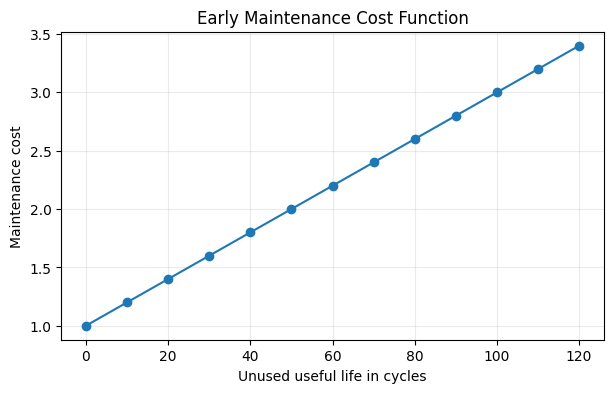

In [68]:
plt.figure(figsize=(7, 4))

plt.plot(
    early_maintenance_cost_preview["unused_life_cycles"],
    early_maintenance_cost_preview["total_planned_cost"],
    marker="o"
)

plt.xlabel("Unused useful life in cycles")
plt.ylabel("Maintenance cost")
plt.title("Early Maintenance Cost Function")
plt.grid(True, alpha=0.25)
plt.show()


In [69]:
# Ensure that the cost model and decision parameters are well-defined.
assert FIXED_MAINTENANCE_INTERVAL > 0
assert POINT_RUL_THRESHOLD >= 0
assert SOFT_UNCERTAINTY_RUL_THRESHOLD >= 0
assert UNCERTAINTY_RUL_THRESHOLD >= 0
assert MAINTENANCE_DELAY_CYCLES >= 0
assert 0 <= SOFT_UNCERTAINTY_LAMBDA <= 1
assert PLANNED_MAINTENANCE_COST >= 0
assert FAILURE_COST > PLANNED_MAINTENANCE_COST
assert EARLY_MAINTENANCE_COST_PER_UNUSED_CYCLE >= 0


# Run Rolling Fleet Simulation

For each engine, windows are processed in chronological order. A policy triggers maintenance at the first window that satisfies its decision rule. Maintenance is then assumed to require a fixed organizational delay. If the engine's remaining useful life is shorter than this delay, the intervention arrives too late and the engine is counted as a failure.

This rolling setup is closer to a fleet-level maintenance process than a single final-cycle decision, because each engine can be reassessed repeatedly as new windows become available.


In [70]:
def planned_maintenance_cost(true_RUL):
    unused_life = max(float(true_RUL), 0.0)
    cost = (
        PLANNED_MAINTENANCE_COST
        + EARLY_MAINTENANCE_COST_PER_UNUSED_CYCLE * unused_life
    )
    return cost, unused_life


def get_policy_decision_rul(row, policy, uncertainty_lambda=1.0):
    if policy == "point_estimate":
        return row["predicted_RUL"]

    if policy == "soft_uncertainty":
        uncertainty_margin = row["predicted_RUL"] - row["RUL_lower"]
        return row["predicted_RUL"] - uncertainty_lambda * uncertainty_margin

    if policy == "uncertainty_aware":
        return row["RUL_lower"]

    if policy == "oracle_last_safe":
        return row["true_RUL"]

    if policy == "fixed_interval":
        return np.nan

    raise ValueError(f"Unknown policy: {policy}")


def should_trigger_maintenance(row, policy, threshold, uncertainty_lambda=1.0):
    if policy == "fixed_interval":
        return row["end_cycle"] % FIXED_MAINTENANCE_INTERVAL == 0

    if policy == "oracle_last_safe":
        raise ValueError("oracle_last_safe is handled directly at engine level.")

    decision_RUL = get_policy_decision_rul(
        row,
        policy=policy,
        uncertainty_lambda=uncertainty_lambda,
    )
    return decision_RUL <= threshold


def evaluate_delayed_maintenance(
    row,
    planned_cost_fn=planned_maintenance_cost,
    failure_cost=FAILURE_COST,
    maintenance_delay_cycles=MAINTENANCE_DELAY_CYCLES,
):
    trigger_cycle = float(row["end_cycle"])
    scheduled_maintenance_cycle = trigger_cycle + maintenance_delay_cycles
    true_failure_cycle = float(row["true_failure_cycle"])

    if scheduled_maintenance_cycle >= true_failure_cycle:
        return {
            "outcome": "failure",
            "cost": failure_cost,
            "unused_life": 0.0,
            "scheduled_maintenance_cycle": scheduled_maintenance_cycle,
            "outcome_cycle": true_failure_cycle,
            "true_RUL_at_maintenance": 0.0,
        }

    true_RUL_at_maintenance = true_failure_cycle - scheduled_maintenance_cycle
    cost, unused_life = planned_cost_fn(true_RUL_at_maintenance)

    return {
        "outcome": "planned_maintenance",
        "cost": cost,
        "unused_life": unused_life,
        "scheduled_maintenance_cycle": scheduled_maintenance_cycle,
        "outcome_cycle": scheduled_maintenance_cycle,
        "true_RUL_at_maintenance": true_RUL_at_maintenance,
    }


def build_policy_result(
    row,
    policy,
    threshold,
    uncertainty_lambda,
    outcome,
    cost,
    unused_life,
    scheduled_maintenance_cycle=np.nan,
    outcome_cycle=np.nan,
    true_RUL_at_maintenance=np.nan,
    maintenance_delay_cycles=MAINTENANCE_DELAY_CYCLES,
):
    if np.isnan(outcome_cycle):
        outcome_cycle = row["true_failure_cycle"] if outcome == "failure" else row["end_cycle"]

    return {
        "engine": row["engine"],
        "policy": policy,
        "threshold": threshold,
        "uncertainty_lambda": uncertainty_lambda,
        "outcome": outcome,
        "decision_cycle": row["end_cycle"],
        "trigger_cycle": row["end_cycle"],
        "scheduled_maintenance_cycle": scheduled_maintenance_cycle,
        "outcome_cycle": outcome_cycle,
        "maintenance_delay_cycles": maintenance_delay_cycles,
        "true_RUL_at_decision": row["true_RUL"],
        "true_RUL_at_maintenance": true_RUL_at_maintenance,
        "predicted_RUL_at_decision": row["predicted_RUL"],
        "RUL_lower_at_decision": row["RUL_lower"],
        "RUL_upper_at_decision": row["RUL_upper"],
        "decision_RUL_at_decision": get_policy_decision_rul(
            row,
            policy=policy,
            uncertainty_lambda=uncertainty_lambda,
        ),
        "true_failure_cycle": row["true_failure_cycle"],
        "unused_life": unused_life,
        "cost": cost,
    }


def simulate_oracle_last_safe(engine_df, maintenance_delay_cycles=MAINTENANCE_DELAY_CYCLES):
    engine_df = engine_df.sort_values("end_cycle")
    safe_windows = engine_df[engine_df["true_RUL"] > maintenance_delay_cycles]

    if safe_windows.empty:
        failure_row = engine_df.iloc[0]
        return build_policy_result(
            row=failure_row,
            policy="oracle_last_safe",
            threshold=np.nan,
            uncertainty_lambda=np.nan,
            outcome="failure",
            cost=FAILURE_COST,
            unused_life=0.0,
            outcome_cycle=failure_row["true_failure_cycle"],
            maintenance_delay_cycles=maintenance_delay_cycles,
        )

    decision_row = safe_windows.iloc[-1]
    delayed_result = evaluate_delayed_maintenance(
        decision_row,
        maintenance_delay_cycles=maintenance_delay_cycles,
    )

    return build_policy_result(
        row=decision_row,
        policy="oracle_last_safe",
        threshold=np.nan,
        uncertainty_lambda=np.nan,
        maintenance_delay_cycles=maintenance_delay_cycles,
        **delayed_result,
    )


def simulate_engine_policy(
    engine_df,
    policy,
    threshold=np.nan,
    uncertainty_lambda=1.0,
    maintenance_delay_cycles=MAINTENANCE_DELAY_CYCLES,
):
    engine_df = engine_df.sort_values("end_cycle")

    if policy == "oracle_last_safe":
        return simulate_oracle_last_safe(
            engine_df,
            maintenance_delay_cycles=maintenance_delay_cycles,
        )

    for _, row in engine_df.iterrows():
        if row["true_RUL"] <= 0:
            return build_policy_result(
                row=row,
                policy=policy,
                threshold=threshold,
                uncertainty_lambda=uncertainty_lambda,
                outcome="failure",
                cost=FAILURE_COST,
                unused_life=0.0,
                outcome_cycle=row["true_failure_cycle"],
                maintenance_delay_cycles=maintenance_delay_cycles,
            )

        if should_trigger_maintenance(
            row,
            policy=policy,
            threshold=threshold,
            uncertainty_lambda=uncertainty_lambda,
        ):
            delayed_result = evaluate_delayed_maintenance(
                row,
                maintenance_delay_cycles=maintenance_delay_cycles,
            )
            return build_policy_result(
                row=row,
                policy=policy,
                threshold=threshold,
                uncertainty_lambda=uncertainty_lambda,
                maintenance_delay_cycles=maintenance_delay_cycles,
                **delayed_result,
            )

    last_row = engine_df.iloc[-1]
    return build_policy_result(
        row=last_row,
        policy=policy,
        threshold=threshold,
        uncertainty_lambda=uncertainty_lambda,
        outcome="failure",
        cost=FAILURE_COST,
        unused_life=0.0,
        outcome_cycle=last_row["true_failure_cycle"],
        maintenance_delay_cycles=maintenance_delay_cycles,
    )


def simulate_fleet_policy(
    fleet_df,
    policy,
    threshold=np.nan,
    uncertainty_lambda=1.0,
    maintenance_delay_cycles=MAINTENANCE_DELAY_CYCLES,
):
    results = []

    for _, engine_df in fleet_df.groupby("engine"):
        results.append(
            simulate_engine_policy(
                engine_df,
                policy=policy,
                threshold=threshold,
                uncertainty_lambda=uncertainty_lambda,
                maintenance_delay_cycles=maintenance_delay_cycles,
            )
        )

    return pd.DataFrame(results)


In [71]:
POLICY_LABELS = {
    "oracle_last_safe": "Oracle last safe",
    "point_estimate": "Point estimate",
    "soft_uncertainty": "Soft uncertainty",
    "uncertainty_aware": "Lower-bound uncertainty",
    "fixed_interval": "Fixed interval",
}

POLICY_PLOT_ORDER = [
    "oracle_last_safe",
    "point_estimate",
    "soft_uncertainty",
    "uncertainty_aware",
    "fixed_interval",
]

OUTCOME_LABELS = {
    "failure": "Failure",
    "planned_maintenance": "Planned maintenance",
}


def add_policy_labels(df, policy_col="policy"):
    labeled_df = df.copy()
    labeled_df["policy_label"] = (
        labeled_df[policy_col]
        .map(POLICY_LABELS)
        .fillna(labeled_df[policy_col])
    )
    return labeled_df


policy_settings = pd.DataFrame([
    {
        "policy": "fixed_interval",
        "threshold": np.nan,
        "uncertainty_lambda": np.nan,
    },
    {
        "policy": "point_estimate",
        "threshold": POINT_RUL_THRESHOLD,
        "uncertainty_lambda": 0.0,
    },
    {
        "policy": "soft_uncertainty",
        "threshold": SOFT_UNCERTAINTY_RUL_THRESHOLD,
        "uncertainty_lambda": SOFT_UNCERTAINTY_LAMBDA,
    },
    {
        "policy": "uncertainty_aware",
        "threshold": UNCERTAINTY_RUL_THRESHOLD,
        "uncertainty_lambda": 1.0,
    },
    {
        "policy": "oracle_last_safe",
        "threshold": np.nan,
        "uncertainty_lambda": np.nan,
    },
])

fleet_simulation_results = pd.concat(
    [
        simulate_fleet_policy(
            fleet_prediction_df,
            policy=row["policy"],
            threshold=row["threshold"],
            uncertainty_lambda=row["uncertainty_lambda"],
            maintenance_delay_cycles=MAINTENANCE_DELAY_CYCLES,
        )
        for _, row in policy_settings.iterrows()
    ],
    ignore_index=True,
)

fleet_simulation_results = add_policy_labels(fleet_simulation_results)
fleet_simulation_results.head(100)


,engine,policy,threshold,uncertainty_lambda,outcome,decision_cycle,trigger_cycle,scheduled_maintenance_cycle,outcome_cycle,maintenance_delay_cycles,true_RUL_at_decision,true_RUL_at_maintenance,predicted_RUL_at_decision,RUL_lower_at_decision,RUL_upper_at_decision,decision_RUL_at_decision,true_failure_cycle,unused_life,cost,policy_label
0,1.0,fixed_interval,NaN,NaN,planned_maintenance,150.0,150.0,155.0,155.0,5,42.0,37.0,71.087959,44.580574,97.595345,NaN,192.0,37.0,1.74,Fixed interval
1,5.0,fixed_interval,NaN,NaN,planned_maintenance,150.0,150.0,155.0,155.0,5,119.0,114.0,118.607155,92.099770,125.000000,NaN,269.0,114.0,3.28,Fixed interval
2,10.0,fixed_interval,NaN,NaN,planned_maintenance,150.0,150.0,155.0,155.0,5,72.0,67.0,103.618721,77.111336,125.000000,NaN,222.0,67.0,2.34,Fixed interval
3,11.0,fixed_interval,NaN,NaN,planned_maintenance,150.0,150.0,155.0,155.0,5,90.0,85.0,91.607582,65.100197,118.114967,NaN,240.0,85.0,2.70,Fixed interval
4,13.0,fixed_interval,NaN,NaN,planned_maintenance,150.0,150.0,155.0,155.0,5,13.0,8.0,15.476126,0.000000,41.983513,NaN,163.0,8.0,1.16,Fixed interval
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,45.0,oracle_last_safe,NaN,NaN,planned_maintenance,152.0,152.0,157.0,157.0,5,6.0,1.0,9.131898,0.000000,35.639282,6.0,158.0,1.0,1.02,Oracle last safe
96,46.0,oracle_last_safe,NaN,NaN,planned_maintenance,250.0,250.0,255.0,255.0,5,6.0,1.0,6.650460,0.000000,33.157845,6.0,256.0,1.0,1.02,Oracle last safe
97,54.0,oracle_last_safe,NaN,NaN,planned_maintenance,251.0,251.0,256.0,256.0,5,6.0,1.0,7.736817,0.000000,34.244202,6.0,257.0,1.0,1.02,Oracle last safe
98,73.0,oracle_last_safe,NaN,NaN,planned_maintenance,207.0,207.0,212.0,212.0,5,6.0,1.0,8.217559,0.000000,34.724945,6.0,213.0,1.0,1.02,Oracle last safe


In [72]:
# Ensure that every policy produces exactly one decision per fleet engine.
expected_rows = len(fleet_engines) * policy_settings.shape[0]
assert fleet_simulation_results.shape[0] == expected_rows

assert (
    fleet_simulation_results
    .groupby("policy")["engine"]
    .nunique()
    .eq(len(fleet_engines))
).all()

valid_outcomes = {"planned_maintenance", "failure"}
assert set(fleet_simulation_results["outcome"]).issubset(valid_outcomes)
assert (fleet_simulation_results["cost"] >= 0).all()


# Compare Fleet-Level Policy Costs

Policy performance is summarized across the simulated fleet. Lower total cost is better under the assumed cost model, but the outcome mix and unused useful life show the trade-off between avoiding failures and intervening early.


In [73]:
def summarize_policy_results(results_df):
    return (
        results_df
        .groupby("policy")
        .agg(
            threshold=("threshold", "first"),
            uncertainty_lambda=("uncertainty_lambda", "first"),
            total_cost=("cost", "sum"),
            mean_cost_per_engine=("cost", "mean"),
            failures=("outcome", lambda s: (s == "failure").sum()),
            planned_maintenance=("outcome", lambda s: (s == "planned_maintenance").sum()),
            mean_unused_life=("unused_life", "mean"),
            median_trigger_cycle=("trigger_cycle", "median"),
            median_outcome_cycle=("outcome_cycle", "median"),
            maintenance_delay_cycles=("maintenance_delay_cycles", "first"),
        )
        .reset_index()
        .pipe(add_policy_labels)
        .sort_values("total_cost")
    )

fleet_policy_summary = summarize_policy_results(fleet_simulation_results)
fleet_policy_summary


,policy,threshold,uncertainty_lambda,total_cost,mean_cost_per_engine,failures,planned_maintenance,mean_unused_life,median_trigger_cycle,median_outcome_cycle,maintenance_delay_cycles,policy_label
1,oracle_last_safe,NaN,NaN,21.42,1.020000,0,21,1.000000,207.0,212.0,5,Oracle last safe
2,point_estimate,20.0,0.0,26.70,1.271429,0,21,13.571429,195.0,200.0,5,Point estimate
3,soft_uncertainty,20.0,0.5,32.58,1.551429,0,21,27.571429,176.0,181.0,5,Soft uncertainty
4,uncertainty_aware,20.0,1.0,39.66,1.888571,0,21,44.428571,154.0,159.0,5,Lower-bound uncertainty
0,fixed_interval,NaN,NaN,60.54,2.882857,2,19,51.285714,150.0,155.0,5,Fixed interval


In [74]:
# Ensure that all policies are represented in the fleet summary.
assert set(fleet_policy_summary["policy"]) == set(policy_settings["policy"])
assert (fleet_policy_summary["total_cost"] >= 0).all()
assert (
    fleet_policy_summary["failures"]
    + fleet_policy_summary["planned_maintenance"]
    == len(fleet_engines)
).all()


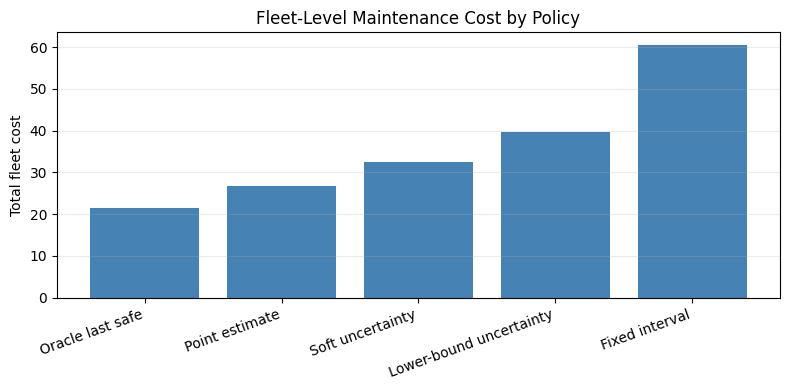

In [75]:
plt.figure(figsize=(8, 4))

plt.bar(
    fleet_policy_summary["policy_label"],
    fleet_policy_summary["total_cost"],
    color="steelblue"
)

plt.ylabel("Total fleet cost")
plt.title("Fleet-Level Maintenance Cost by Policy")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


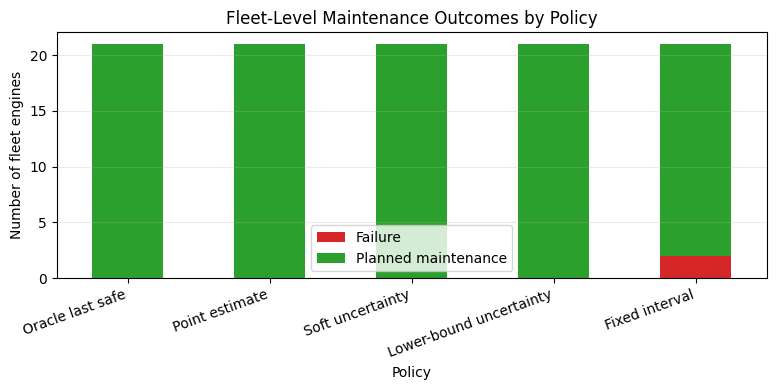

In [76]:
policy_outcome_plot_data = (
    fleet_policy_summary
    .set_index("policy_label")[["failures", "planned_maintenance"]]
    .rename(columns={
        "failures": OUTCOME_LABELS["failure"],
        "planned_maintenance": OUTCOME_LABELS["planned_maintenance"],
    })
)

policy_outcome_plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 4),
    color=["tab:red", "tab:green"]
)

plt.xlabel("Policy")
plt.ylabel("Number of fleet engines")
plt.title("Fleet-Level Maintenance Outcomes by Policy")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [77]:
model_based_policy_summary = fleet_policy_summary[
    fleet_policy_summary["policy"].isin([
        "point_estimate",
        "soft_uncertainty",
        "uncertainty_aware",
    ])
].copy()

model_based_policy_summary


,policy,threshold,uncertainty_lambda,total_cost,mean_cost_per_engine,failures,planned_maintenance,mean_unused_life,median_trigger_cycle,median_outcome_cycle,maintenance_delay_cycles,policy_label
2,point_estimate,20.0,0.0,26.70,1.271429,0,21,13.571429,195.0,200.0,5,Point estimate
3,soft_uncertainty,20.0,0.5,32.58,1.551429,0,21,27.571429,176.0,181.0,5,Soft uncertainty
4,uncertainty_aware,20.0,1.0,39.66,1.888571,0,21,44.428571,154.0,159.0,5,Lower-bound uncertainty


The point-estimate policy acts only on the model's predicted RUL. The soft uncertainty policy subtracts a configurable fraction of the conformal uncertainty margin from the point prediction. The hard uncertainty-aware policy uses the lower conformal bound directly.

This creates a gradual risk-control scale: `lambda = 0` behaves like point-estimate scheduling, while `lambda = 1` behaves like lower-bound scheduling. Intermediate values can reduce failure risk without becoming as conservative as the full lower-bound policy.


# Threshold Sensitivity: Point Estimate vs Uncertainty-Aware

The threshold sensitivity analysis evaluates both model-based policies across the same threshold grid. This shows whether the uncertainty-aware policy changes the cost-failure trade-off compared with point-estimate scheduling.


In [78]:
threshold_grid = np.arange(5, RUL_CAP + 1, 5)
threshold_policy_settings = pd.DataFrame([
    {
        "policy": "point_estimate",
        "uncertainty_lambda": 0.0,
    },
    {
        "policy": "soft_uncertainty",
        "uncertainty_lambda": SOFT_UNCERTAINTY_LAMBDA,
    },
    {
        "policy": "uncertainty_aware",
        "uncertainty_lambda": 1.0,
    },
])

threshold_results = []

for threshold in threshold_grid:
    for _, policy_row in threshold_policy_settings.iterrows():
        policy_results = simulate_fleet_policy(
            fleet_prediction_df,
            policy=policy_row["policy"],
            threshold=threshold,
            uncertainty_lambda=policy_row["uncertainty_lambda"],
        )
        summary = summarize_policy_results(policy_results).iloc[0]
        threshold_results.append({
            "threshold": threshold,
            "policy": policy_row["policy"],
            "uncertainty_lambda": policy_row["uncertainty_lambda"],
            "total_cost": summary["total_cost"],
            "mean_cost_per_engine": summary["mean_cost_per_engine"],
            "failures": summary["failures"],
            "planned_maintenance": summary["planned_maintenance"],
            "mean_unused_life": summary["mean_unused_life"],
            "threshold_dependent": True,
        })

threshold_results = add_policy_labels(pd.DataFrame(threshold_results))

# Add threshold-independent policies as horizontal references for all threshold plots.
reference_policy_summary = fleet_policy_summary[
    fleet_policy_summary["policy"].isin(["fixed_interval", "oracle_last_safe"])
]

threshold_reference_results = []

for threshold in threshold_grid:
    for _, summary in reference_policy_summary.iterrows():
        threshold_reference_results.append({
            "threshold": threshold,
            "policy": summary["policy"],
            "uncertainty_lambda": summary["uncertainty_lambda"],
            "total_cost": summary["total_cost"],
            "mean_cost_per_engine": summary["mean_cost_per_engine"],
            "failures": summary["failures"],
            "planned_maintenance": summary["planned_maintenance"],
            "mean_unused_life": summary["mean_unused_life"],
            "threshold_dependent": False,
        })

threshold_reference_results = add_policy_labels(pd.DataFrame(threshold_reference_results))

threshold_plot_results = pd.concat(
    [threshold_results, threshold_reference_results],
    ignore_index=True,
)

threshold_plot_results.head()


,threshold,policy,uncertainty_lambda,total_cost,mean_cost_per_engine,failures,planned_maintenance,mean_unused_life,threshold_dependent,policy_label
0,5,point_estimate,0.0,174.38,8.303810,17,4,0.904762,True,Point estimate
1,5,soft_uncertainty,0.5,49.72,2.367619,3,18,4.095238,True,Soft uncertainty
2,5,uncertainty_aware,1.0,32.30,1.538095,0,21,26.904762,True,Lower-bound uncertainty
3,10,point_estimate,0.0,49.72,2.367619,3,18,4.095238,True,Point estimate
4,10,soft_uncertainty,0.5,26.70,1.271429,0,21,13.571429,True,Soft uncertainty


In [79]:
best_thresholds = (
    threshold_results
    .sort_values("total_cost")
    .groupby("policy")
    .head(1)
    .reset_index(drop=True)
)

best_thresholds


,threshold,policy,uncertainty_lambda,total_cost,mean_cost_per_engine,failures,planned_maintenance,mean_unused_life,threshold_dependent,policy_label
0,15,point_estimate,0.0,24.86,1.183810,0,21,9.190476,True,Point estimate
1,10,soft_uncertainty,0.5,26.70,1.271429,0,21,13.571429,True,Soft uncertainty
2,5,uncertainty_aware,1.0,32.30,1.538095,0,21,26.904762,True,Lower-bound uncertainty


In [80]:
# Ensure that threshold sensitivity contains all policies at every threshold.
expected_threshold_policies = set(threshold_policy_settings["policy"]).union(
    {"fixed_interval", "oracle_last_safe"}
)

assert set(threshold_plot_results["policy"]) == expected_threshold_policies
assert threshold_plot_results.groupby("threshold")["policy"].nunique().eq(
    len(expected_threshold_policies)
).all()
assert (threshold_plot_results["total_cost"] >= 0).all()
assert (
    threshold_plot_results["failures"]
    + threshold_plot_results["planned_maintenance"]
    == len(fleet_engines)
).all()

# Keep the model-based threshold table available for selecting best threshold-dependent policies.
assert set(threshold_results["policy"]) == set(threshold_policy_settings["policy"])


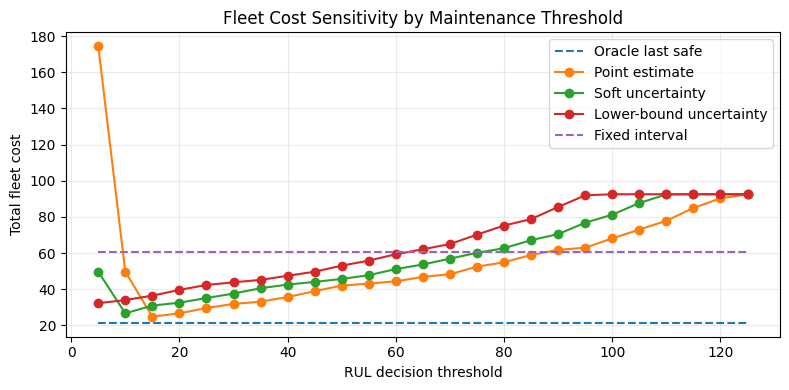

In [81]:
plt.figure(figsize=(8, 4))

for policy in POLICY_PLOT_ORDER:
    policy_df = threshold_plot_results[
        threshold_plot_results["policy"] == policy
    ]

    if policy_df.empty:
        continue

    line_style = "--" if not policy_df["threshold_dependent"].iloc[0] else "-"
    marker = None if not policy_df["threshold_dependent"].iloc[0] else "o"

    plt.plot(
        policy_df["threshold"],
        policy_df["total_cost"],
        marker=marker,
        linestyle=line_style,
        label=POLICY_LABELS.get(policy, policy),
    )

plt.xlabel("RUL decision threshold")
plt.ylabel("Total fleet cost")
plt.title("Fleet Cost Sensitivity by Maintenance Threshold")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


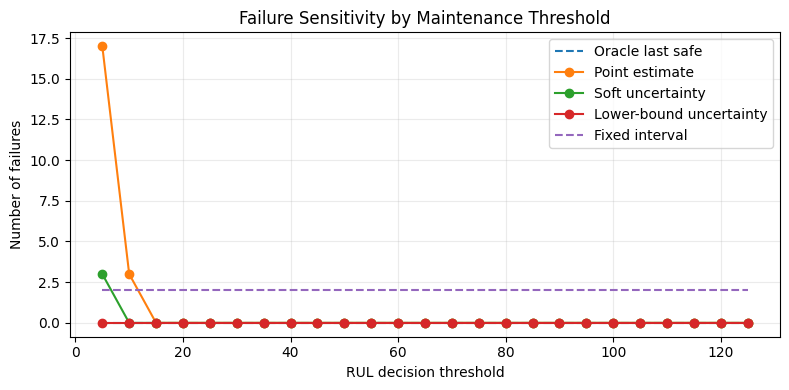

In [82]:
plt.figure(figsize=(8, 4))

for policy in POLICY_PLOT_ORDER:
    policy_df = threshold_plot_results[
        threshold_plot_results["policy"] == policy
    ]

    if policy_df.empty:
        continue

    line_style = "--" if not policy_df["threshold_dependent"].iloc[0] else "-"
    marker = None if not policy_df["threshold_dependent"].iloc[0] else "o"

    plt.plot(
        policy_df["threshold"],
        policy_df["failures"],
        marker=marker,
        linestyle=line_style,
        label=POLICY_LABELS.get(policy, policy),
    )

plt.xlabel("RUL decision threshold")
plt.ylabel("Number of failures")
plt.title("Failure Sensitivity by Maintenance Threshold")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


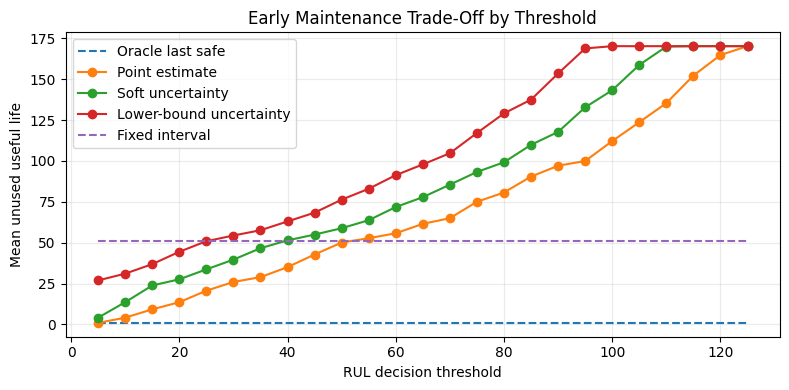

In [83]:
plt.figure(figsize=(8, 4))

for policy in POLICY_PLOT_ORDER:
    policy_df = threshold_plot_results[
        threshold_plot_results["policy"] == policy
    ]

    if policy_df.empty:
        continue

    line_style = "--" if not policy_df["threshold_dependent"].iloc[0] else "-"
    marker = None if not policy_df["threshold_dependent"].iloc[0] else "o"

    plt.plot(
        policy_df["threshold"],
        policy_df["mean_unused_life"],
        marker=marker,
        linestyle=line_style,
        label=POLICY_LABELS.get(policy, policy),
    )

plt.xlabel("RUL decision threshold")
plt.ylabel("Mean unused useful life")
plt.title("Early Maintenance Trade-Off by Threshold")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


The threshold plots show the operational trade-off directly. Low thresholds postpone maintenance and can lead to more failures. Higher thresholds trigger maintenance earlier, reducing failures but increasing unused useful life.

The threshold-dependent policies are shown as solid lines. The fixed-interval and oracle-last-safe policies are included as dashed horizontal references because they do not use a RUL decision threshold. This keeps all policies visible in the sensitivity plots while making clear which policies actually change with the threshold.

The soft uncertainty policy should lie between point-estimate and hard lower-bound scheduling when the same threshold is used. It provides a tunable compromise: it accounts for uncertainty, but does not automatically act as early as the full lower-bound rule.


# Lambda Sensitivity for Soft Uncertainty

The soft uncertainty parameter controls how much of the conformal uncertainty margin is subtracted from the point prediction before making a maintenance decision. This section keeps the decision threshold fixed and varies only `lambda` to show how conservative uncertainty-aware scheduling should be.


In [84]:
lambda_grid = np.round(np.linspace(0, 1, 11), 2)
lambda_results = []

for uncertainty_lambda in lambda_grid:
    policy_results = simulate_fleet_policy(
        fleet_prediction_df,
        policy="soft_uncertainty",
        threshold=SOFT_UNCERTAINTY_RUL_THRESHOLD,
        uncertainty_lambda=uncertainty_lambda,
    )
    summary = summarize_policy_results(policy_results).iloc[0]
    lambda_results.append({
        "uncertainty_lambda": uncertainty_lambda,
        "threshold": SOFT_UNCERTAINTY_RUL_THRESHOLD,
        "total_cost": summary["total_cost"],
        "mean_cost_per_engine": summary["mean_cost_per_engine"],
        "failures": summary["failures"],
        "planned_maintenance": summary["planned_maintenance"],
        "mean_unused_life": summary["mean_unused_life"],
    })

lambda_results = pd.DataFrame(lambda_results)
lambda_results


,uncertainty_lambda,threshold,total_cost,mean_cost_per_engine,failures,planned_maintenance,mean_unused_life
0,0.0,20,26.70,1.271429,0,21,13.571429
1,0.1,20,28.30,1.347619,0,21,17.380952
2,0.2,20,29.66,1.412381,0,21,20.619048
3,0.3,20,30.90,1.471429,0,21,23.571429
4,0.4,20,32.14,1.530476,0,21,26.523810
5,0.5,20,32.58,1.551429,0,21,27.571429
6,0.6,20,33.50,1.595238,0,21,29.761905
7,0.7,20,35.36,1.683810,0,21,34.190476
8,0.8,20,36.32,1.729524,0,21,36.476190
9,0.9,20,38.38,1.827619,0,21,41.380952


In [85]:
best_lambda_row = lambda_results.loc[
    lambda_results["total_cost"].idxmin()
]

best_lambda_row


uncertainty_lambda       0.000000
threshold               20.000000
total_cost              26.700000
mean_cost_per_engine     1.271429
failures                 0.000000
planned_maintenance     21.000000
mean_unused_life        13.571429
Name: 0, dtype: float64

In [86]:
# Ensure that lambda sensitivity spans the full point-to-lower-bound range.
assert lambda_results["uncertainty_lambda"].min() == 0
assert lambda_results["uncertainty_lambda"].max() == 1
assert (lambda_results["total_cost"] >= 0).all()
assert (
    lambda_results["failures"]
    + lambda_results["planned_maintenance"]
    == len(fleet_engines)
).all()


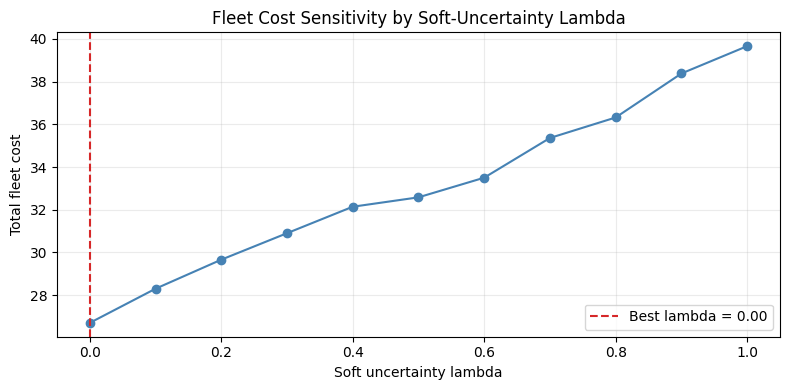

In [87]:
plt.figure(figsize=(8, 4))

plt.plot(
    lambda_results["uncertainty_lambda"],
    lambda_results["total_cost"],
    marker="o",
    color="steelblue"
)

plt.axvline(
    best_lambda_row["uncertainty_lambda"],
    color="tab:red",
    linestyle="--",
    label=f"Best lambda = {best_lambda_row['uncertainty_lambda']:.2f}"
)

plt.xlabel("Soft uncertainty lambda")
plt.ylabel("Total fleet cost")
plt.title("Fleet Cost Sensitivity by Soft-Uncertainty Lambda")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


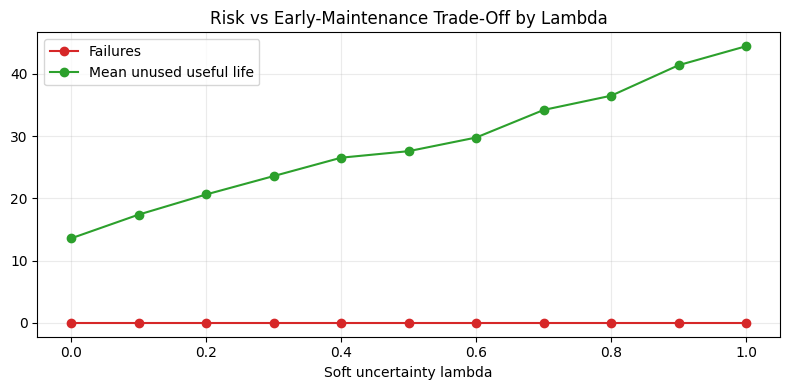

In [88]:
plt.figure(figsize=(8, 4))

plt.plot(
    lambda_results["uncertainty_lambda"],
    lambda_results["failures"],
    marker="o",
    label="Failures",
    color="tab:red"
)

plt.plot(
    lambda_results["uncertainty_lambda"],
    lambda_results["mean_unused_life"],
    marker="o",
    label="Mean unused useful life",
    color="tab:green"
)

plt.xlabel("Soft uncertainty lambda")
plt.title("Risk vs Early-Maintenance Trade-Off by Lambda")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


The lambda sensitivity isolates the value of uncertainty information from the choice of threshold. Increasing `lambda` makes the policy more conservative: it reacts not only to the point prediction, but also to how low the conformal lower bound could be.

If total cost rises with larger `lambda`, the current cost model penalizes early maintenance more strongly than it rewards the additional failure-risk reduction. If an intermediate `lambda` is best, partial uncertainty awareness provides a better trade-off than either pure point estimates or full lower-bound scheduling.


# Maintenance Delay Sensitivity

The base simulation assumes a fixed delay between triggering maintenance and completing the intervention. This sensitivity analysis varies that delay to show how organizational lead time affects cost and failure risk. Longer delays make late predictions more dangerous, because a policy may trigger maintenance before failure but still not leave enough time to execute it.


In [89]:
maintenance_delay_grid = [0, 2, 5, 10, 15]

delay_sensitivity_results = []

for maintenance_delay in maintenance_delay_grid:
    for _, policy_row in policy_settings.iterrows():
        policy_results = simulate_fleet_policy(
            fleet_prediction_df,
            policy=policy_row["policy"],
            threshold=policy_row["threshold"],
            uncertainty_lambda=policy_row["uncertainty_lambda"],
            maintenance_delay_cycles=maintenance_delay,
        )
        summary = summarize_policy_results(policy_results).iloc[0]
        delay_sensitivity_results.append({
            "maintenance_delay_cycles": maintenance_delay,
            "policy": policy_row["policy"],
            "total_cost": summary["total_cost"],
            "mean_cost_per_engine": summary["mean_cost_per_engine"],
            "failures": summary["failures"],
            "planned_maintenance": summary["planned_maintenance"],
            "mean_unused_life": summary["mean_unused_life"],
        })

delay_sensitivity_results = add_policy_labels(pd.DataFrame(delay_sensitivity_results))
delay_sensitivity_results.head(100)


,maintenance_delay_cycles,policy,total_cost,mean_cost_per_engine,failures,planned_maintenance,mean_unused_life,policy_label
0,0,fixed_interval,53.52,2.548571,1,20,56.000000,Fixed interval
1,0,point_estimate,28.80,1.371429,0,21,18.571429,Point estimate
2,0,soft_uncertainty,34.68,1.651429,0,21,32.571429,Soft uncertainty
3,0,uncertainty_aware,41.76,1.988571,0,21,49.428571,Lower-bound uncertainty
4,0,oracle_last_safe,21.42,1.020000,0,21,1.000000,Oracle last safe
5,2,fixed_interval,52.72,2.510476,1,20,54.095238,Fixed interval
6,2,point_estimate,27.96,1.331429,0,21,16.571429,Point estimate
7,2,soft_uncertainty,33.84,1.611429,0,21,30.571429,Soft uncertainty
8,2,uncertainty_aware,40.92,1.948571,0,21,47.428571,Lower-bound uncertainty
9,2,oracle_last_safe,21.42,1.020000,0,21,1.000000,Oracle last safe


In [90]:
# Ensure that delay sensitivity contains all policies for every delay value.
assert delay_sensitivity_results.groupby("maintenance_delay_cycles")["policy"].nunique().eq(
    policy_settings.shape[0]
).all()
assert (delay_sensitivity_results["total_cost"] >= 0).all()
assert (
    delay_sensitivity_results["failures"]
    + delay_sensitivity_results["planned_maintenance"]
    == len(fleet_engines)
).all()


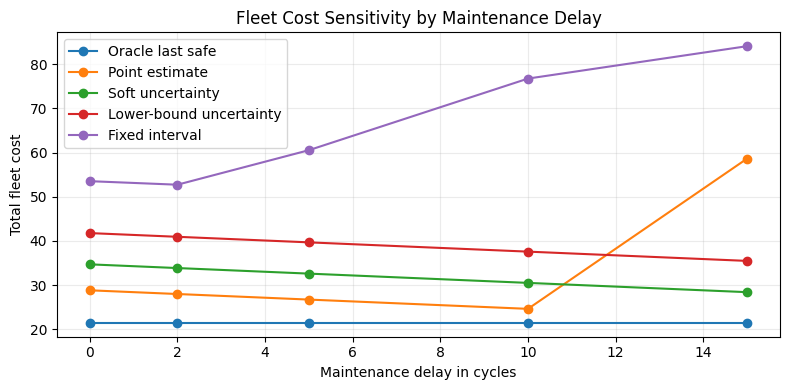

In [91]:
plt.figure(figsize=(8, 4))

for policy in POLICY_PLOT_ORDER:
    policy_df = delay_sensitivity_results[
        delay_sensitivity_results["policy"] == policy
    ]

    if policy_df.empty:
        continue

    plt.plot(
        policy_df["maintenance_delay_cycles"],
        policy_df["total_cost"],
        marker="o",
        label=POLICY_LABELS.get(policy, policy),
    )

plt.xlabel("Maintenance delay in cycles")
plt.ylabel("Total fleet cost")
plt.title("Fleet Cost Sensitivity by Maintenance Delay")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


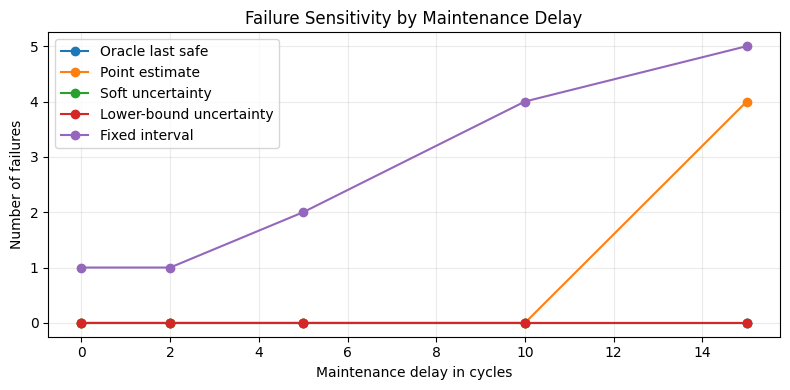

In [92]:
plt.figure(figsize=(8, 4))

for policy in POLICY_PLOT_ORDER:
    policy_df = delay_sensitivity_results[
        delay_sensitivity_results["policy"] == policy
    ]

    if policy_df.empty:
        continue

    plt.plot(
        policy_df["maintenance_delay_cycles"],
        policy_df["failures"],
        marker="o",
        label=POLICY_LABELS.get(policy, policy),
    )

plt.xlabel("Maintenance delay in cycles")
plt.ylabel("Number of failures")
plt.title("Failure Sensitivity by Maintenance Delay")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


The maintenance-delay analysis makes the simulation stricter than an instant-action policy. A model can only prevent failure if it triggers early enough to cover the operational lead time. This is useful for the thesis discussion because it connects prediction timeliness to a concrete scheduling constraint.


# Cost Parameter Sensitivity

The previous results depend on the assumed cost model. This section varies the failure cost and the early-maintenance penalty to test whether the preferred maintenance policy changes under different economic assumptions.

This is especially important for uncertainty-aware scheduling: conservative policies may look too expensive when early maintenance is costly, but they can become attractive when failures are much more expensive than planned interventions.


In [93]:
failure_cost_grid = [5.0, 10.0, 20.0, 50.0]
early_cost_grid = [0.005, 0.01, 0.02, 0.05]

cost_sensitivity_policies = pd.DataFrame([
    {
        "policy": "fixed_interval",
        "threshold": np.nan,
        "uncertainty_lambda": np.nan,
    },
    {
        "policy": "point_estimate",
        "threshold": POINT_RUL_THRESHOLD,
        "uncertainty_lambda": 0.0,
    },
    {
        "policy": "soft_uncertainty",
        "threshold": SOFT_UNCERTAINTY_RUL_THRESHOLD,
        "uncertainty_lambda": SOFT_UNCERTAINTY_LAMBDA,
    },
    {
        "policy": "uncertainty_aware",
        "threshold": UNCERTAINTY_RUL_THRESHOLD,
        "uncertainty_lambda": 1.0,
    },
    {
        "policy": "oracle_last_safe",
        "threshold": np.nan,
        "uncertainty_lambda": np.nan,
    },
])

cost_sensitivity_policies


,policy,threshold,uncertainty_lambda
0,fixed_interval,NaN,NaN
1,point_estimate,20.0,0.0
2,soft_uncertainty,20.0,0.5
3,uncertainty_aware,20.0,1.0
4,oracle_last_safe,NaN,NaN


In [94]:
def planned_maintenance_cost_for_scenario(
    true_RUL,
    planned_cost,
    early_cost_per_cycle,
):
    unused_life = max(float(true_RUL), 0.0)
    cost = planned_cost + early_cost_per_cycle * unused_life
    return cost, unused_life


def make_planned_cost_fn(planned_cost, early_cost_per_cycle):
    return lambda true_RUL: planned_maintenance_cost_for_scenario(
        true_RUL,
        planned_cost=planned_cost,
        early_cost_per_cycle=early_cost_per_cycle,
    )


def simulate_oracle_last_safe_for_cost_scenario(
    engine_df,
    planned_cost,
    failure_cost,
    early_cost_per_cycle,
    maintenance_delay_cycles=MAINTENANCE_DELAY_CYCLES,
):
    engine_df = engine_df.sort_values("end_cycle")
    safe_windows = engine_df[engine_df["true_RUL"] > maintenance_delay_cycles]

    if safe_windows.empty:
        failure_row = engine_df.iloc[0]
        return build_policy_result(
            row=failure_row,
            policy="oracle_last_safe",
            threshold=np.nan,
            uncertainty_lambda=np.nan,
            outcome="failure",
            cost=failure_cost,
            unused_life=0.0,
            outcome_cycle=failure_row["true_failure_cycle"],
            maintenance_delay_cycles=maintenance_delay_cycles,
        )

    decision_row = safe_windows.iloc[-1]
    delayed_result = evaluate_delayed_maintenance(
        decision_row,
        planned_cost_fn=make_planned_cost_fn(planned_cost, early_cost_per_cycle),
        failure_cost=failure_cost,
        maintenance_delay_cycles=maintenance_delay_cycles,
    )

    return build_policy_result(
        row=decision_row,
        policy="oracle_last_safe",
        threshold=np.nan,
        uncertainty_lambda=np.nan,
        maintenance_delay_cycles=maintenance_delay_cycles,
        **delayed_result,
    )


def simulate_engine_policy_for_cost_scenario(
    engine_df,
    policy,
    threshold,
    uncertainty_lambda,
    planned_cost,
    failure_cost,
    early_cost_per_cycle,
    maintenance_delay_cycles=MAINTENANCE_DELAY_CYCLES,
):
    engine_df = engine_df.sort_values("end_cycle")

    if policy == "oracle_last_safe":
        return simulate_oracle_last_safe_for_cost_scenario(
            engine_df,
            planned_cost=planned_cost,
            failure_cost=failure_cost,
            early_cost_per_cycle=early_cost_per_cycle,
            maintenance_delay_cycles=maintenance_delay_cycles,
        )

    planned_cost_fn = make_planned_cost_fn(planned_cost, early_cost_per_cycle)

    for _, row in engine_df.iterrows():
        if row["true_RUL"] <= 0:
            return build_policy_result(
                row=row,
                policy=policy,
                threshold=threshold,
                uncertainty_lambda=uncertainty_lambda,
                outcome="failure",
                cost=failure_cost,
                unused_life=0.0,
                outcome_cycle=row["true_failure_cycle"],
                maintenance_delay_cycles=maintenance_delay_cycles,
            )

        if should_trigger_maintenance(
            row,
            policy=policy,
            threshold=threshold,
            uncertainty_lambda=uncertainty_lambda,
        ):
            delayed_result = evaluate_delayed_maintenance(
                row,
                planned_cost_fn=planned_cost_fn,
                failure_cost=failure_cost,
                maintenance_delay_cycles=maintenance_delay_cycles,
            )
            return build_policy_result(
                row=row,
                policy=policy,
                threshold=threshold,
                uncertainty_lambda=uncertainty_lambda,
                maintenance_delay_cycles=maintenance_delay_cycles,
                **delayed_result,
            )

    last_row = engine_df.iloc[-1]
    return build_policy_result(
        row=last_row,
        policy=policy,
        threshold=threshold,
        uncertainty_lambda=uncertainty_lambda,
        outcome="failure",
        cost=failure_cost,
        unused_life=0.0,
        outcome_cycle=last_row["true_failure_cycle"],
        maintenance_delay_cycles=maintenance_delay_cycles,
    )


def simulate_fleet_policy_for_cost_scenario(
    fleet_df,
    policy,
    threshold,
    uncertainty_lambda,
    planned_cost,
    failure_cost,
    early_cost_per_cycle,
    maintenance_delay_cycles=MAINTENANCE_DELAY_CYCLES,
):
    results = []

    for _, engine_df in fleet_df.groupby("engine"):
        results.append(
            simulate_engine_policy_for_cost_scenario(
                engine_df,
                policy=policy,
                threshold=threshold,
                uncertainty_lambda=uncertainty_lambda,
                planned_cost=planned_cost,
                failure_cost=failure_cost,
                early_cost_per_cycle=early_cost_per_cycle,
                maintenance_delay_cycles=maintenance_delay_cycles,
            )
        )

    return pd.DataFrame(results)


In [95]:
cost_sensitivity_results = []

for failure_cost in failure_cost_grid:
    for early_cost_per_cycle in early_cost_grid:
        for _, policy_row in cost_sensitivity_policies.iterrows():
            scenario_results = simulate_fleet_policy_for_cost_scenario(
                fleet_prediction_df,
                policy=policy_row["policy"],
                threshold=policy_row["threshold"],
                uncertainty_lambda=policy_row["uncertainty_lambda"],
                planned_cost=PLANNED_MAINTENANCE_COST,
                failure_cost=failure_cost,
                early_cost_per_cycle=early_cost_per_cycle,
                maintenance_delay_cycles=MAINTENANCE_DELAY_CYCLES,
            )
            summary = summarize_policy_results(scenario_results).iloc[0]
            cost_sensitivity_results.append({
                "failure_cost": failure_cost,
                "early_cost_per_cycle": early_cost_per_cycle,
                "policy": policy_row["policy"],
                "total_cost": summary["total_cost"],
                "mean_cost_per_engine": summary["mean_cost_per_engine"],
                "failures": summary["failures"],
                "planned_maintenance": summary["planned_maintenance"],
                "mean_unused_life": summary["mean_unused_life"],
            })

cost_sensitivity_results = add_policy_labels(pd.DataFrame(cost_sensitivity_results))
cost_sensitivity_results.head(1000)


,failure_cost,early_cost_per_cycle,policy,total_cost,mean_cost_per_engine,failures,planned_maintenance,mean_unused_life,policy_label
0,5.0,0.005,fixed_interval,34.385,1.637381,2,19,51.285714,Fixed interval
1,5.0,0.005,point_estimate,22.425,1.067857,0,21,13.571429,Point estimate
2,5.0,0.005,soft_uncertainty,23.895,1.137857,0,21,27.571429,Soft uncertainty
3,5.0,0.005,uncertainty_aware,25.665,1.222143,0,21,44.428571,Lower-bound uncertainty
4,5.0,0.005,oracle_last_safe,21.105,1.005000,0,21,1.000000,Oracle last safe
...,...,...,...,...,...,...,...,...,...
75,50.0,0.050,fixed_interval,172.850,8.230952,2,19,51.285714,Fixed interval
76,50.0,0.050,point_estimate,35.250,1.678571,0,21,13.571429,Point estimate
77,50.0,0.050,soft_uncertainty,49.950,2.378571,0,21,27.571429,Soft uncertainty
78,50.0,0.050,uncertainty_aware,67.650,3.221429,0,21,44.428571,Lower-bound uncertainty


In [96]:
# Ensure that every cost scenario contains one result for every policy.
expected_policy_count = cost_sensitivity_policies.shape[0]

assert (
    cost_sensitivity_results
    .groupby(["failure_cost", "early_cost_per_cycle"])["policy"]
    .nunique()
    .eq(expected_policy_count)
).all()

assert (cost_sensitivity_results["total_cost"] >= 0).all()
assert (
    cost_sensitivity_results["failures"]
    + cost_sensitivity_results["planned_maintenance"]
    == len(fleet_engines)
).all()


In [97]:
best_policy_by_cost_scenario = (
    cost_sensitivity_results
    .sort_values("total_cost")
    .groupby(["failure_cost", "early_cost_per_cycle"])
    .head(1)
    .reset_index(drop=True)
)

best_policy_by_cost_scenario


,failure_cost,early_cost_per_cycle,policy,total_cost,mean_cost_per_engine,failures,planned_maintenance,mean_unused_life,policy_label
0,50.0,0.005,oracle_last_safe,21.105,1.005,0,21,1.0,Oracle last safe
1,5.0,0.005,oracle_last_safe,21.105,1.005,0,21,1.0,Oracle last safe
2,20.0,0.005,oracle_last_safe,21.105,1.005,0,21,1.0,Oracle last safe
3,10.0,0.005,oracle_last_safe,21.105,1.005,0,21,1.0,Oracle last safe
4,50.0,0.010,oracle_last_safe,21.210,1.010,0,21,1.0,Oracle last safe
5,20.0,0.010,oracle_last_safe,21.210,1.010,0,21,1.0,Oracle last safe
6,5.0,0.010,oracle_last_safe,21.210,1.010,0,21,1.0,Oracle last safe
7,10.0,0.010,oracle_last_safe,21.210,1.010,0,21,1.0,Oracle last safe
8,50.0,0.020,oracle_last_safe,21.420,1.020,0,21,1.0,Oracle last safe
9,20.0,0.020,oracle_last_safe,21.420,1.020,0,21,1.0,Oracle last safe


In [98]:
best_policy_counts = (
    best_policy_by_cost_scenario["policy"]
    .value_counts()
    .rename_axis("policy")
    .reset_index(name="best_scenarios")
    .pipe(add_policy_labels)
    [["policy", "policy_label", "best_scenarios"]]
)

best_policy_counts


,policy,policy_label,best_scenarios
0,oracle_last_safe,Oracle last safe,16


In [99]:
# Compare practical policies against the point-estimate baseline across cost scenarios.
point_costs = cost_sensitivity_results[
    cost_sensitivity_results["policy"] == "point_estimate"
][[
    "failure_cost",
    "early_cost_per_cycle",
    "total_cost",
]].rename(columns={"total_cost": "point_estimate_total_cost"})

cost_delta_vs_point = cost_sensitivity_results.merge(
    point_costs,
    on=["failure_cost", "early_cost_per_cycle"],
    how="left",
)

cost_delta_vs_point["cost_delta_vs_point"] = (
    cost_delta_vs_point["total_cost"]
    - cost_delta_vs_point["point_estimate_total_cost"]
)

cost_delta_vs_point.head()


,failure_cost,early_cost_per_cycle,policy,total_cost,mean_cost_per_engine,failures,planned_maintenance,mean_unused_life,policy_label,point_estimate_total_cost,cost_delta_vs_point
0,5.0,0.005,fixed_interval,34.385,1.637381,2,19,51.285714,Fixed interval,22.425,11.96
1,5.0,0.005,point_estimate,22.425,1.067857,0,21,13.571429,Point estimate,22.425,0.00
2,5.0,0.005,soft_uncertainty,23.895,1.137857,0,21,27.571429,Soft uncertainty,22.425,1.47
3,5.0,0.005,uncertainty_aware,25.665,1.222143,0,21,44.428571,Lower-bound uncertainty,22.425,3.24
4,5.0,0.005,oracle_last_safe,21.105,1.005000,0,21,1.000000,Oracle last safe,22.425,-1.32


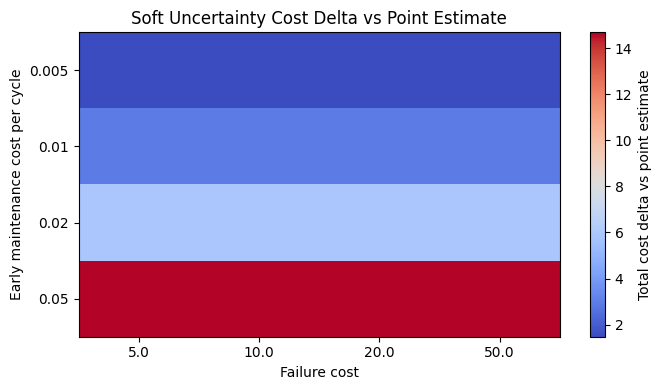

In [100]:
soft_delta_heatmap = (
    cost_delta_vs_point[
        cost_delta_vs_point["policy"] == "soft_uncertainty"
    ]
    .pivot_table(
        index="early_cost_per_cycle",
        columns="failure_cost",
        values="cost_delta_vs_point",
    )
)

plt.figure(figsize=(7, 4))
plt.imshow(
    soft_delta_heatmap,
    aspect="auto",
    cmap="coolwarm",
)

plt.xticks(
    ticks=np.arange(len(soft_delta_heatmap.columns)),
    labels=soft_delta_heatmap.columns,
)
plt.yticks(
    ticks=np.arange(len(soft_delta_heatmap.index)),
    labels=soft_delta_heatmap.index,
)
plt.colorbar(label="Total cost delta vs point estimate")
plt.xlabel("Failure cost")
plt.ylabel("Early maintenance cost per cycle")
plt.title("Soft Uncertainty Cost Delta vs Point Estimate")
plt.tight_layout()
plt.show()


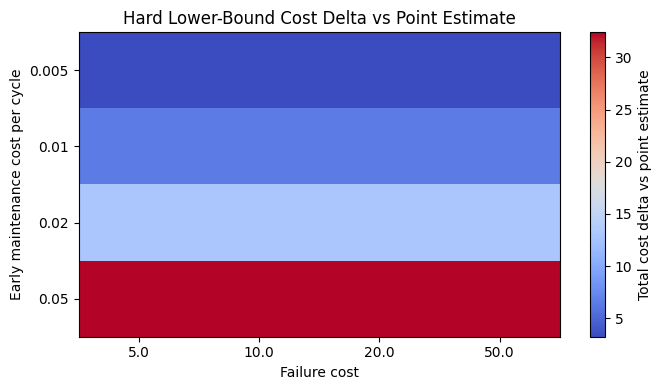

In [101]:
hard_delta_heatmap = (
    cost_delta_vs_point[
        cost_delta_vs_point["policy"] == "uncertainty_aware"
    ]
    .pivot_table(
        index="early_cost_per_cycle",
        columns="failure_cost",
        values="cost_delta_vs_point",
    )
)

plt.figure(figsize=(7, 4))
plt.imshow(
    hard_delta_heatmap,
    aspect="auto",
    cmap="coolwarm",
)

plt.xticks(
    ticks=np.arange(len(hard_delta_heatmap.columns)),
    labels=hard_delta_heatmap.columns,
)
plt.yticks(
    ticks=np.arange(len(hard_delta_heatmap.index)),
    labels=hard_delta_heatmap.index,
)
plt.colorbar(label="Total cost delta vs point estimate")
plt.xlabel("Failure cost")
plt.ylabel("Early maintenance cost per cycle")
plt.title("Hard Lower-Bound Cost Delta vs Point Estimate")
plt.tight_layout()
plt.show()


In [102]:
oracle_costs = cost_sensitivity_results[
    cost_sensitivity_results["policy"] == "oracle_last_safe"
][[
    "failure_cost",
    "early_cost_per_cycle",
    "total_cost",
]].rename(columns={"total_cost": "oracle_total_cost"})

cost_gap_to_oracle = cost_sensitivity_results.merge(
    oracle_costs,
    on=["failure_cost", "early_cost_per_cycle"],
    how="left",
)

cost_gap_to_oracle["cost_gap_to_oracle"] = (
    cost_gap_to_oracle["total_cost"]
    - cost_gap_to_oracle["oracle_total_cost"]
)

cost_gap_to_oracle.head()


,failure_cost,early_cost_per_cycle,policy,total_cost,mean_cost_per_engine,failures,planned_maintenance,mean_unused_life,policy_label,oracle_total_cost,cost_gap_to_oracle
0,5.0,0.005,fixed_interval,34.385,1.637381,2,19,51.285714,Fixed interval,21.105,13.28
1,5.0,0.005,point_estimate,22.425,1.067857,0,21,13.571429,Point estimate,21.105,1.32
2,5.0,0.005,soft_uncertainty,23.895,1.137857,0,21,27.571429,Soft uncertainty,21.105,2.79
3,5.0,0.005,uncertainty_aware,25.665,1.222143,0,21,44.428571,Lower-bound uncertainty,21.105,4.56
4,5.0,0.005,oracle_last_safe,21.105,1.005000,0,21,1.000000,Oracle last safe,21.105,0.00


The cost sensitivity analysis tests whether the policy ranking is stable under different cost assumptions. Positive cost deltas in the heatmaps mean that the uncertainty-aware policy is more expensive than the point-estimate policy for that scenario; negative values would indicate that uncertainty-aware scheduling reduces total fleet cost.

This analysis is important because the value of uncertainty depends on the relative economics of the maintenance problem. If failures are extremely expensive and early maintenance is cheap, conservative uncertainty-aware scheduling can become more attractive. If early maintenance is expensive, lower-bound policies may trigger too early and increase total cost.


# Simulation Takeaways

The fleet-level simulation connects RUL prediction to maintenance cost over multiple validation engines and multiple decision windows per engine.

The data split is engine-wise throughout the workflow. With the Notebook 07 simulation-specific configuration, roughly 70 engines fit the XGBoost model, about 10 held-out validation engines calibrate the conformal interval width and about 20 held-out validation engines form the simulated fleet. This larger validation split is applied only in this simulation notebook and does not change the default split used by the earlier model-comparison notebooks. This keeps model training, uncertainty calibration and final fleet-cost evaluation separated by machine unit.

Using validation run-to-failure trajectories allows the simulation to evaluate rolling decisions over time. Each engine is reassessed chronologically until maintenance is triggered or failure is reached. This would not be possible with the official test labels alone, because they provide true RUL only at the final observed test cycle.

The point-estimate policy schedules maintenance based on the XGBoost-predicted RUL. The hard uncertainty-aware policy schedules maintenance based on the lower conformal RUL bound, making it more conservative when prediction uncertainty is large.

The added soft uncertainty policy introduces a tunable middle ground. It subtracts only a fraction of the conformal uncertainty margin from the point prediction. This allows the simulation to test whether partial uncertainty awareness reduces failure risk without triggering maintenance as early as the full lower-bound policy.

The `oracle_last_safe` policy is an idealized lower-bound reference. It uses true RUL and schedules maintenance at the last available safe window before failure, so it is not available in practice but represents near-perfect timing under the simplified rolling-window setup.

The fleet-level comparison reports total cost, failures, planned maintenance and unused useful life. This is more informative than regression metrics alone because it translates prediction errors into operational consequences.

The threshold, lambda, maintenance-delay and cost-parameter sensitivity analyses show how the trade-off changes between late maintenance risk, organizational lead time and early maintenance cost. The preferred threshold, uncertainty lambda and even the preferred policy depend directly on the assumed failure cost, planned maintenance cost and early-maintenance penalty.

The simulation remains simplified. It uses one global conformal interval width, a simple cost model, a fixed maintenance delay and one maintenance action per engine. However, it directly addresses the thesis extension by comparing point-estimate, soft uncertainty-aware, hard lower-bound and ideal oracle maintenance scheduling at fleet level.
